<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/Olist_Brazillian_Sales_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏬 Project Overview: Olist E-Commerce Analytics**
**Dataset:** Olist Brazilian E-Commerce (100k+ orders from 2016-2018).

**Business Context:** Olist is a marketplace that connects small businesses from all over Brazil to channels without hassle.

**Master File:** Olist_Gold_Master.csv (The "Gold View" joined via SQL).

## **The 3 Numerical Features:**

**payment_value** (Total money paid by the customer)

**price** (The cost of the actual item)

**freight_value** (This is the third one! The shipping cost)

**The 6 Categorical/Date Features**:

4.  **order_id** (Unique ID)
5.  **customer_city** (Location)
6.  **product_category_name_english** (What they bought - e.g., "health_beauty")
7.  **payment_type** (Credit card, boleto, voucher)
8.  **customer_state** (Location)
9.  **order_purchase_timestamp** (When they bought it)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PowerTransformer  #outliers removal technique

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Olist_Gold_Sales_master.csv',header=0)

In [34]:
df.head()

,order_id,order_purchase_timestamp,customer_city,customer_state,product_category_name_english,price,freight_value,payment_type,payment_value
0,0006ec9db01a64e59a68b2c340bf65a7,2018-07-24 17:04:17.0000000,rio de janeiro,RJ,bed_bath_table,74.000000,23.320000,credit_card,97.320000
1,0035246a40f520710769010f752e7507,2017-08-17 00:57:23.0000000,sao paulo,SP,bed_bath_table,87.000000,12.110000,credit_card,99.110001
2,00858d03144cc35cfd1dd043647e7c88,2018-03-14 22:53:09.0000000,gravatai,RS,home_appliances,165.000000,19.030001,credit_card,184.029999
3,00a843f5a80c7aea894c558acc29f513,2017-09-01 13:09:44.0000000,porto alegre,RS,fixed_telephony,32.990002,14.100000,credit_card,47.090000
4,00d5fac7792747fba4b528f23930bebd,2018-03-06 11:33:17.0000000,sao paulo,SP,sports_leisure,64.900002,15.330000,credit_card,80.230003


In [35]:
# EDA
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113384 entries, 0 to 113383
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113384 non-null  object 
 1   order_purchase_timestamp       113384 non-null  object 
 2   customer_city                  113384 non-null  object 
 3   customer_state                 113384 non-null  object 
 4   product_category_name_english  113384 non-null  object 
 5   price                          113384 non-null  float64
 6   freight_value                  113384 non-null  float64
 7   payment_type                   113384 non-null  object 
 8   payment_value                  113384 non-null  float64
dtypes: float64(3), object(6)
memory usage: 7.8+ MB


In [36]:
df.isnull().sum()

,0
order_id,0
order_purchase_timestamp,0
customer_city,0
customer_state,0
product_category_name_english,0
price,0
freight_value,0
payment_type,0
payment_value,0


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,113384.0,120.181296,182.784475,0.85,39.900002,74.900002,133.899994,6735.000000
freight_value,113384.0,20.024209,15.752274,0.00,13.080000,16.320000,21.200001,409.679993
payment_value,113384.0,172.237301,266.611670,0.00,61.000000,108.150002,189.369995,13664.080078


In [38]:
df.shape

(113384, 9)

In [39]:
df.drop_duplicates(inplace = True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101762 entries, 0 to 113383
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       101762 non-null  object 
 1   order_purchase_timestamp       101762 non-null  object 
 2   customer_city                  101762 non-null  object 
 3   customer_state                 101762 non-null  object 
 4   product_category_name_english  101762 non-null  object 
 5   price                          101762 non-null  float64
 6   freight_value                  101762 non-null  float64
 7   payment_type                   101762 non-null  object 
 8   payment_value                  101762 non-null  float64
dtypes: float64(3), object(6)
memory usage: 7.8+ MB


In [41]:
df.head()

,order_id,order_purchase_timestamp,customer_city,customer_state,product_category_name_english,price,freight_value,payment_type,payment_value
0,0006ec9db01a64e59a68b2c340bf65a7,2018-07-24 17:04:17.0000000,rio de janeiro,RJ,bed_bath_table,74.000000,23.320000,credit_card,97.320000
1,0035246a40f520710769010f752e7507,2017-08-17 00:57:23.0000000,sao paulo,SP,bed_bath_table,87.000000,12.110000,credit_card,99.110001
2,00858d03144cc35cfd1dd043647e7c88,2018-03-14 22:53:09.0000000,gravatai,RS,home_appliances,165.000000,19.030001,credit_card,184.029999
3,00a843f5a80c7aea894c558acc29f513,2017-09-01 13:09:44.0000000,porto alegre,RS,fixed_telephony,32.990002,14.100000,credit_card,47.090000
4,00d5fac7792747fba4b528f23930bebd,2018-03-06 11:33:17.0000000,sao paulo,SP,sports_leisure,64.900002,15.330000,credit_card,80.230003


In [42]:
# Select numeric columns
nums_cols = df.select_dtypes(include='number').columns

In [43]:
 # Outlier detection using IQR
for col in nums_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    lower_limit = q1 - 1.5 * IQR
    upper_limit = q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    # Print the numerical count
    print(f"Column: {col} | Number of outliers: {len(outliers)}")

Column: price | Number of outliers: 7684
Column: freight_value | Number of outliers: 11079
Column: payment_value | Number of outliers: 7821


In [44]:
# removing skewness(make data normally distributed)
pt = PowerTransformer(method='yeo-johnson')
df[nums_cols] = pt.fit_transform(df[nums_cols])


In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,101762.0,1.522163e-17,1.000005,-5.108886,-0.682100,0.056193,0.668058,3.986671
freight_value,101762.0,9.967722e-16,1.000005,-5.593511,-0.472045,-0.082456,0.391471,5.873010
payment_value,101762.0,4.401703e-16,1.000005,-4.831153,-0.636441,-0.019156,0.587492,5.875261


In [46]:
 # Outlier detection using IQR
print('After PowerTransformed')
for col in nums_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    lower_limit = q1 - 1.5 * IQR
    upper_limit = q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    # Print the numerical count
    print(f"Column: {col} | Number of outliers: {len(outliers)}")

After PowerTransformed
Column: price | Number of outliers: 835
Column: freight_value | Number of outliers: 7058
Column: payment_value | Number of outliers: 2797


In [47]:
# outlier removal
for col in nums_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_limit = q1 - 1.5 * IQR
    upper_limit = q3 + 1.5 * IQR
    # Capping logic:
    #Just limit extremes instead of removing.
    # If value < lower_limit, replace with lower_limit
    # If value > upper_limit, replace with upper_limit
    '''
    df[col] = np.where(df[col] < lower_limit, lower_limit,
              np.where(df[col] > upper_limit, upper_limit, df[col]))
    '''
    df[col] = np.clip(df[col], lower_limit, upper_limit)

print("Outliers Winsorization/capping done successfully.")

Outliers Winsorization/capping done successfully.


In [48]:
 # Outlier detection using IQR
for col in nums_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    lower_limit = q1 - 1.5 * IQR
    upper_limit = q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    # Print the numerical count
    print(f"Column: {col} | Number of outliers: {len(outliers)}")

Column: price | Number of outliers: 0
Column: freight_value | Number of outliers: 0
Column: payment_value | Number of outliers: 0


In [49]:
df[nums_cols].skew()


,0
price,-0.012268
freight_value,0.279935
payment_value,0.150640


In [50]:
# 1. Ensure you only pass numeric columns (no dates or text)
nums_col = df.select_dtypes(include='number')

# 2. Build the VIF DataFrame
vif = pd.DataFrame() # Changed df.DataFrame() to pd.DataFrame()
vif['features'] = nums_col.columns

# 3. Calculate VIF (Fixed the 'num_cols' typo in the loop)
vif['multicollinearity'] = [variance_inflation_factor(nums_col.values, i) for i in range(len(nums_col.columns))]

# 4. Sort to see the worst offenders at the top
print(vif.sort_values('multicollinearity', ascending=False))

        features  multicollinearity
2  payment_value           3.442869
0          price           3.402804
1  freight_value           1.276173


<Axes: ylabel='Count'>

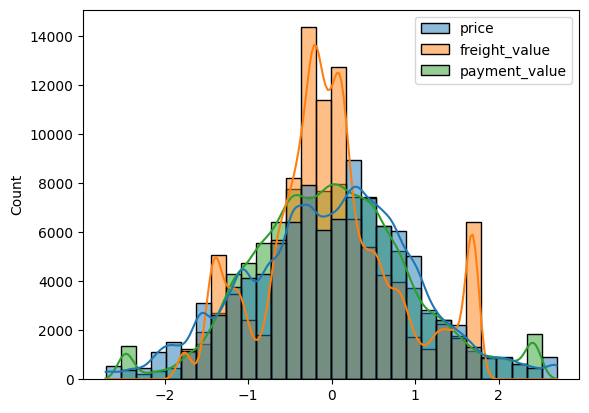

In [51]:
sns.histplot(nums_col, bins= 30, kde = True)

our data is moderate skewed

<Axes: >

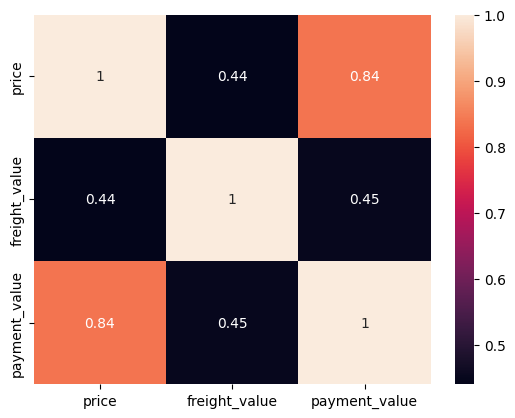

In [52]:
sns.heatmap(df[nums_cols].corr(), annot = True)

In [53]:
df['order_purchase_timestamp']= pd.to_datetime(df['order_purchase_timestamp'])

In [54]:
df[['order_purchase_timestamp','payment_value']]

,order_purchase_timestamp,payment_value
0,2018-07-24 17:04:17,-0.074562
1,2017-08-17 00:57:23,-0.054459
2,2018-03-14 22:53:09,0.636871
3,2017-09-01 13:09:44,-0.862227
4,2018-03-06 11:33:17,-0.286616
...,...,...
113379,2017-11-05 22:16:07,-0.069024
113380,2018-03-24 10:16:33,1.468119
113381,2017-12-18 22:26:02,-0.426979
113382,2018-03-24 01:41:40,0.200791


In [55]:
df #here numeric columns are normalised mean = 0, std = 1

,order_id,order_purchase_timestamp,customer_city,customer_state,product_category_name_english,price,freight_value,payment_type,payment_value
0,0006ec9db01a64e59a68b2c340bf65a7,2018-07-24 17:04:17,rio de janeiro,RJ,bed_bath_table,-0.008568,0.556494,credit_card,-0.074562
1,0035246a40f520710769010f752e7507,2017-08-17 00:57:23,sao paulo,SP,bed_bath_table,0.169079,-0.622003,credit_card,-0.054459
2,00858d03144cc35cfd1dd043647e7c88,2018-03-14 22:53:09,gravatai,RS,home_appliances,0.844952,0.187002,credit_card,0.636871
3,00a843f5a80c7aea894c558acc29f513,2017-09-01 13:09:44,porto alegre,RS,fixed_telephony,-0.934651,-0.351962,credit_card,-0.862227
4,00d5fac7792747fba4b528f23930bebd,2018-03-06 11:33:17,sao paulo,SP,sports_leisure,-0.154578,-0.202457,credit_card,-0.286616
...,...,...,...,...,...,...,...,...,...
113379,f6b73cb42a81880d54cdbf2059599d93,2017-11-05 22:16:07,sao caetano do sul,SP,bed_bath_table,0.077344,0.067230,credit_card,-0.069024
113380,f6cf8d4fd766fb0bd2d664fbbc94e9b7,2018-03-24 10:16:33,praia grande,SP,perfumery,1.611507,0.313031,credit_card,1.468119
113381,f6f02e9abb77e86bfac81d2912451366,2017-12-18 22:26:02,balneario camboriu,SC,home_construction,-0.353717,-0.110080,credit_card,-0.426979
113382,fbbd2baf2d839f10d73c99b4642ce46b,2018-03-24 01:41:40,goiania,GO,pet_shop,0.298031,0.808733,credit_card,0.200791


In [56]:
df['order_purchase_day'] = df['order_purchase_timestamp'].dt.day
df['order_purchase_month'] = df['order_purchase_timestamp'].dt.month
df['order_purchase_year'] = df['order_purchase_timestamp'].dt.year
df['order_purchase_hour'] = df['order_purchase_timestamp'].dt.hour

#drop order_purchase_timestamp
df.drop(['order_purchase_timestamp'], axis = 1, inplace = True)


In [57]:
df.head()

,order_id,customer_city,customer_state,product_category_name_english,price,freight_value,payment_type,payment_value,order_purchase_day,order_purchase_month,order_purchase_year,order_purchase_hour
0,0006ec9db01a64e59a68b2c340bf65a7,rio de janeiro,RJ,bed_bath_table,-0.008568,0.556494,credit_card,-0.074562,24,7,2018,17
1,0035246a40f520710769010f752e7507,sao paulo,SP,bed_bath_table,0.169079,-0.622003,credit_card,-0.054459,17,8,2017,0
2,00858d03144cc35cfd1dd043647e7c88,gravatai,RS,home_appliances,0.844952,0.187002,credit_card,0.636871,14,3,2018,22
3,00a843f5a80c7aea894c558acc29f513,porto alegre,RS,fixed_telephony,-0.934651,-0.351962,credit_card,-0.862227,1,9,2017,13
4,00d5fac7792747fba4b528f23930bebd,sao paulo,SP,sports_leisure,-0.154578,-0.202457,credit_card,-0.286616,6,3,2018,11


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101762 entries, 0 to 113383
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       101762 non-null  object 
 1   customer_city                  101762 non-null  object 
 2   customer_state                 101762 non-null  object 
 3   product_category_name_english  101762 non-null  object 
 4   price                          101762 non-null  float64
 5   freight_value                  101762 non-null  float64
 6   payment_type                   101762 non-null  object 
 7   payment_value                  101762 non-null  float64
 8   order_purchase_day             101762 non-null  int32  
 9   order_purchase_month           101762 non-null  int32  
 10  order_purchase_year            101762 non-null  int32  
 11  order_purchase_hour            101762 non-null  int32  
dtypes: float64(3), int32(4), object(5)


In [59]:
features = df[['product_category_name_english','payment_type','order_purchase_day','order_purchase_month','order_purchase_year','order_purchase_hour']]
target = df['payment_value']

In [60]:
!rm -rf my_dir